In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
from demler_tools.file_manager import file_management_local_backend

import data_analysis as da
from glob import glob                                                                             
import os 

In [2]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-17-g6b0081d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [3]:
crt_controlling_machine = 'laptop'

file_management_local_backend.simple_result_scan(_scan_path = path_management.default_simulation_data_path(running_machine = crt_controlling_machine), display_full_parameters = True)

Directory 1781604188 is missing common arguments file! Please construct it.
Directory 1781604188:

      Human-readable file created at Tue Jun 16 12:03:08 2026, using demler_tools v2.3.0-beta-17-g6b0081d
      Path convention: v3
      Created by user: fmarijanovic
      Project name: psBQP-keldysh
      
      Calculation type: Linear response
      Number of jobs to run: 1
      
      Task summary: Testing newest code for equilibration and current
      
      Current folder state: completed
      
      Calculation log:
      [Tue Jun 16 12:04:00 2026] Updated directory state to the following: submitted
      [Tue Jun 16 12:04:00 2026] Submitted folder job to cluster with controller cluster_files/cluster_control_0_main.sh and under ID: 3559064
      [Tue Jun 16 12:04:01 2026] Submitted automatic postprocess job to cluster with controller cluster_files/cluster_control_0_post.sh and under ID: 3559088
      [Tue Jun 16 13:21:53 2026] Recovered slurm metadata for job ID: 3559064
     

['1780855200',
 '1780855166',
 '1780854842',
 '1780851032',
 '1780846595',
 '1780842396',
 '1780826466',
 '1780820543',
 '1780783363',
 '1780778728',
 '1780771988',
 '1780771986',
 '1780771984',
 '1780769806',
 '1780759388',
 '1780758797',
 '1780758027']

In [4]:
import pickle

def load_gap_vs_temperature(filename=None, directory='equilibrium_results'):
    """
    Load gap vs temperature data from text file.

    If filename is None, loads the most recent gap_vs_T file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_vs_T_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_vs_T files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    T = data[:, 0]           # Temperature
    Re_gap = data[:, 1]      # Re(Gap)
    Im_gap = data[:, 2]      # Im(Gap)
    abs_gap = data[:, 3]     # |Gap|
    error = data[:, 4]       # Error

    # Reconstruct complex gap
    gap = Re_gap + 1j * Im_gap

    return {
        'temperature': T,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'error': error
    }

  # ============================================================================
  # Load Gap & Current vs Vector Potential Data
  # ============================================================================

def load_gap_current_vs_A(filename=None, directory='equilibrium_results'):
    """
    Load gap and current vs vector potential data from text file.

    If filename is None, loads the most recent gap_current_vs_A file.
    """
    if filename is None:
        # Find most recent file
        files = glob(os.path.join(directory, 'gap_current_vs_A_sweep_*.txt'))
        if not files:
            raise FileNotFoundError(f"No gap_current_vs_A files found in {directory}")
        filename = max(files, key=os.path.getmtime)

    print(f"Loading: {filename}")

    # Load data (skip comment lines starting with #)
    data = np.loadtxt(filename, comments='#')

    # Extract columns
    A = data[:, 0]              # Vector potential
    Re_gap = data[:, 1]         # Re(Gap)
    Im_gap = data[:, 2]         # Im(Gap)
    abs_gap = data[:, 3]        # |Gap|
    Re_current = data[:, 4]     # Re(Current)
    Im_current = data[:, 5]     # Im(Current)
    abs_current = data[:, 6]    # |Current|
    error = data[:, 7]          # Gap error

    # Reconstruct complex values
    gap = Re_gap + 1j * Im_gap
    current = Re_current + 1j * Im_current

    return {
        'vector_potential': A,
        'gap': gap,
        'gap_real': Re_gap,
        'gap_imag': Im_gap,
        'gap_magnitude': abs_gap,
        'current': current,
        'current_real': Re_current,
        'current_imag': Im_current,
        'current_magnitude': abs_current,
        'error': error
    }

def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

temp_data = load_gap_vs_temperature('./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt')
A_data = load_gap_current_vs_A('./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt')
# ============================================================================
# Quick Access to Data
# ============================================================================

# Temperature sweep
eq_T = temp_data['temperature']
eq_gap_T = temp_data['gap']
eq_gap_mag_T = temp_data['gap_magnitude']

# Vector potential sweep
eq_A = A_data['vector_potential']
eq_gap_A = A_data['gap']
eq_current_A = A_data['current']
eq_gap_mag_A = A_data['gap_magnitude']
eq_current_mag_A = A_data['current_magnitude']

full_file = load_file('equilibrium_comparison_trash.dat')
print(full_file.keys())

eq_T_trash = full_file['temp_list']
eq_gap_T_trash = full_file['t_scan_gaps']
eq_gap_mag_T_trash = full_file['t_scan_gaps']

# Vector potential sweep
eq_A_trash = full_file['q_scan_Qs']
eq_gap_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_A_trash = full_file['q_scan_currents'][0,:]
eq_gap_mag_A_trash = full_file['q_scan_gaps'][0,:]
eq_current_mag_A_trash = full_file['q_scan_currents'][0,:]


full_file = load_file('equilibrium_comparison.dat')
print(full_file.keys())

eq_T = full_file['temp_list']
eq_gap_T = full_file['t_scan_gaps']
eq_gap_mag_T = full_file['t_scan_gaps']

# Vector potential sweep
eq_A = full_file['q_scan_Qs']
eq_gap_A = full_file['q_scan_gaps'][0,:]
eq_current_A = full_file['q_scan_currents'][0,:]
eq_gap_mag_A = full_file['q_scan_gaps'][0,:]
eq_current_mag_A = full_file['q_scan_currents'][0,:]


print(eq_A.shape)
print(eq_gap_A.shape)
print(eq_current_A.shape)

Loading: ./equilibrium_results/gap_vs_T_sweep_20260610_110914.txt
Loading: ./equilibrium_results/gap_current_vs_A_sweep_20260610_112441.txt
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'temp_list', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
(30,)
(30,)
(30,)


In [5]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1781598564' # 1780851032' #'1780846595'
check_job_index = 0             # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1781598564, job index: 0


# 1. Validation Checks


NORMALIZATION CHECK - Maximum Error Indices

τ_0 component:
  g^R normalization: max_error = 1.1467e-15 at index 1452
  g^R normalization: total_integral = -7.9466e-17
  g^K normalization: max_error = 1.4364e+00 at index 1449
  g^K normalization: total_integral = 1.3733e-01

τ_1 component:
  g^R normalization: max_error = 3.0442e-09 at index 1
  g^R normalization: total_integral = -1.4497e-52
  g^K normalization: max_error = 6.1741e+00 at index 1499
  g^K normalization: total_integral = 6.6817e+01

τ_2 component:
  g^R normalization: max_error = 5.1348e-16 at index 1413
  g^R normalization: total_integral = -8.7195e-17
  g^K normalization: max_error = 1.3323e-15 at index 1500
  g^K normalization: total_integral = -8.5674e-17

τ_3 component:
  g^R normalization: max_error = 6.1062e-16 at index 1346
  g^R normalization: total_integral = 7.0003e-17
  g^K normalization: max_error = 4.9127e-15 at index 1486
  g^K normalization: total_integral = -3.1453e-16


PLOTTING GR NORMALIZATION - Err

/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/data_analysis.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  gr_total_integrals[pauli_idx] = np.sum(gr_totals[pauli_idx, :]) * dt


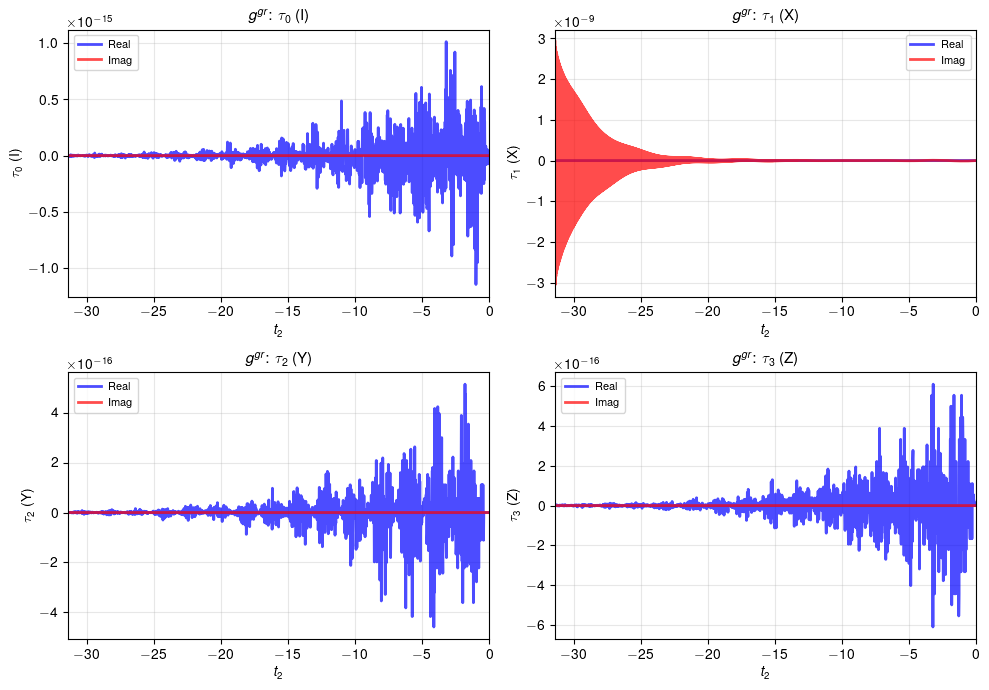


PLOTTING GK NORMALIZATION - Error Values

τ_0 component:
  Plotting range: [-5.4158e-01, 1.4348e+00]
  Mean error: 5.5272e-02
  Std deviation: 2.9819e-01
  Max error: 1.4364e+00

τ_1 component:
  Plotting range: [-7.2164e-16, 3.1917e-02]
  Mean error: 2.1264e-05
  Std deviation: 8.2355e-04
  Max error: 6.1741e+00

τ_2 component:
  Plotting range: [-3.4230e-34, 1.1285e-35]
  Mean error: -2.2871e-37
  Std deviation: 8.8404e-36
  Max error: 1.3323e-15

τ_3 component:
  Plotting range: [-9.7801e-36, 1.6400e-35]
  Mean error: 3.5405e-37
  Std deviation: 3.1146e-36
  Max error: 4.9127e-15



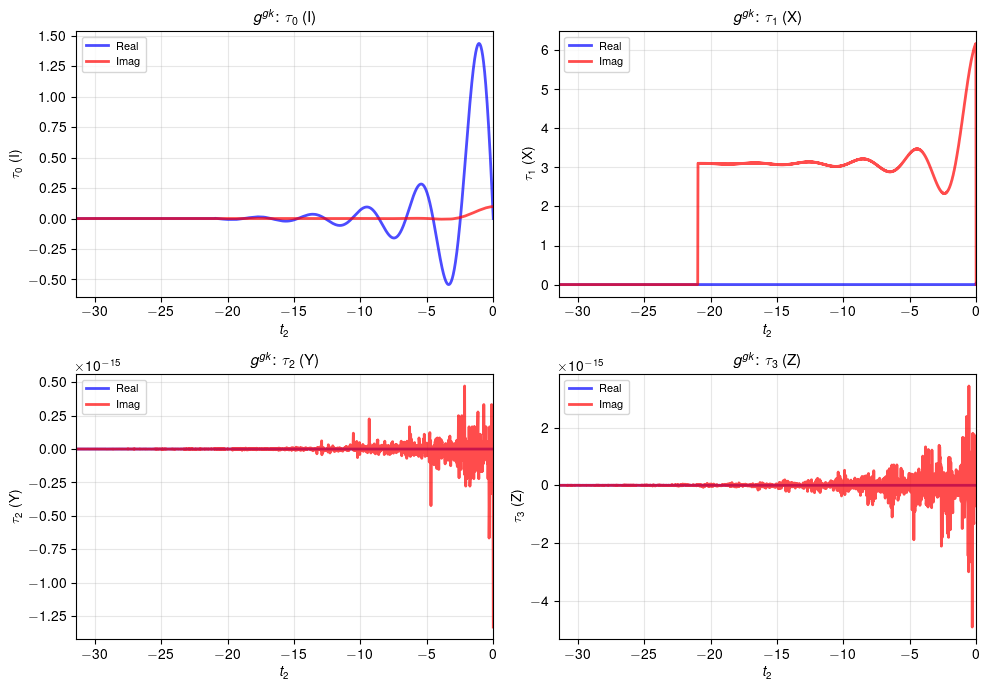


Normalization Check Results:
  gr errors per channel:
    τ₀: 1.15e-15
    τ₁: 3.04e-09
    τ₂: 5.13e-16
    τ₃: 6.11e-16
  gr max error: 3.04e-09 (in channel τ₁)

  gk errors per channel:
    τ₀: 1.44e+00
    τ₁: 6.17e+00
    τ₂: 1.33e-15
    τ₃: 4.91e-15
  gk max error: 6.17e+00 (in channel τ₁)


In [6]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"\nNormalization Check Results:")
print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")


FDT CHECK - Maximum Error Indices

τ_0 component:
  max_error = 9.9920e-16 at index 1427
  total_integral = -5.4166e-36

τ_1 component:
  max_error = 8.8818e-16 at index 1440
  total_integral = 5.5670e-17

τ_2 component:
  max_error = 3.0872e+00 at index 1499
  total_integral = -3.3409e+01

τ_3 component:
  max_error = 7.1740e-01 at index 1449
  total_integral = -8.6879e-01



/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/data_analysis.py:258: ComplexWarning: Casting complex values to real discards the imaginary part
  total_integrals[pauli_idx] = np.sum(error_pauli) * dt


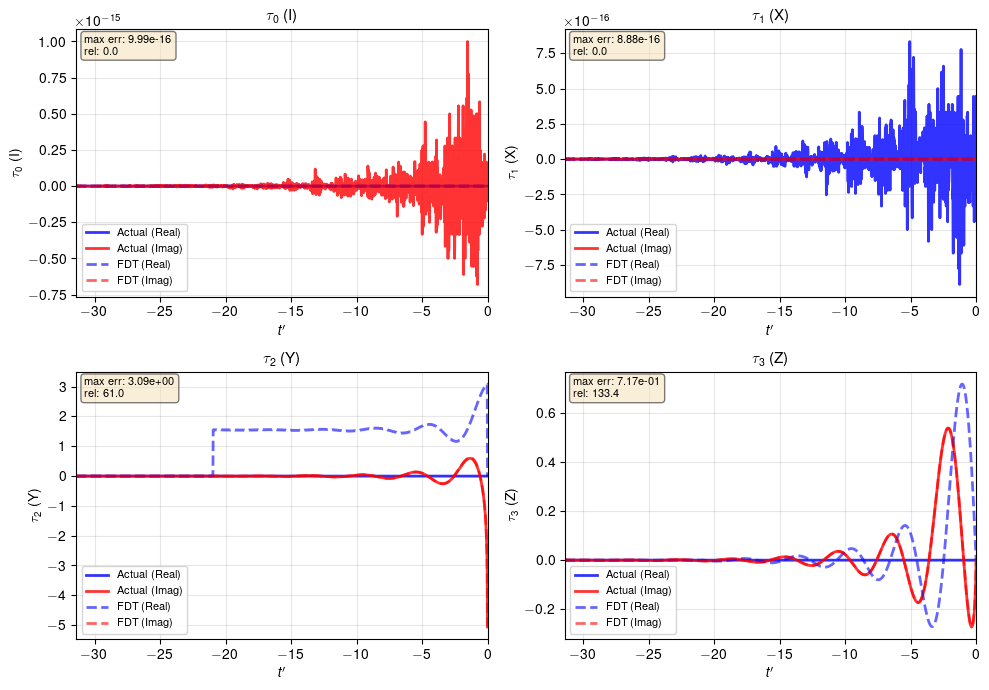


FDT Check Results:
  Errors per channel:
    τ₀: 9.99e-16
    τ₁: 8.88e-16
    τ₂: 3.09e+00
    τ₃: 7.17e-01
  Max error: 3.09e+00 (in channel τ₂)


In [7]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

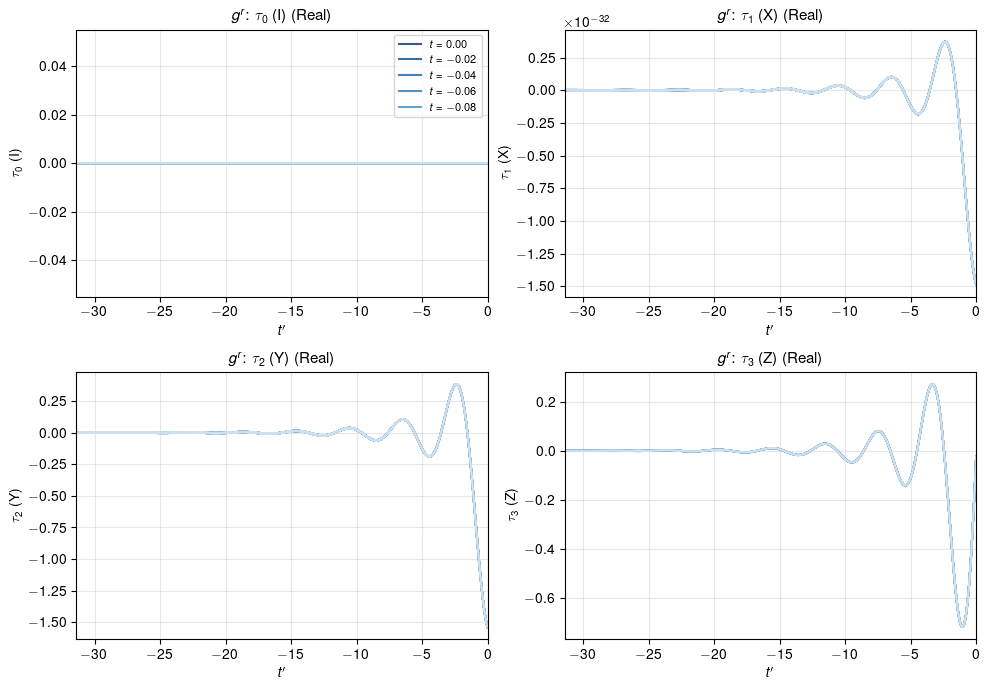

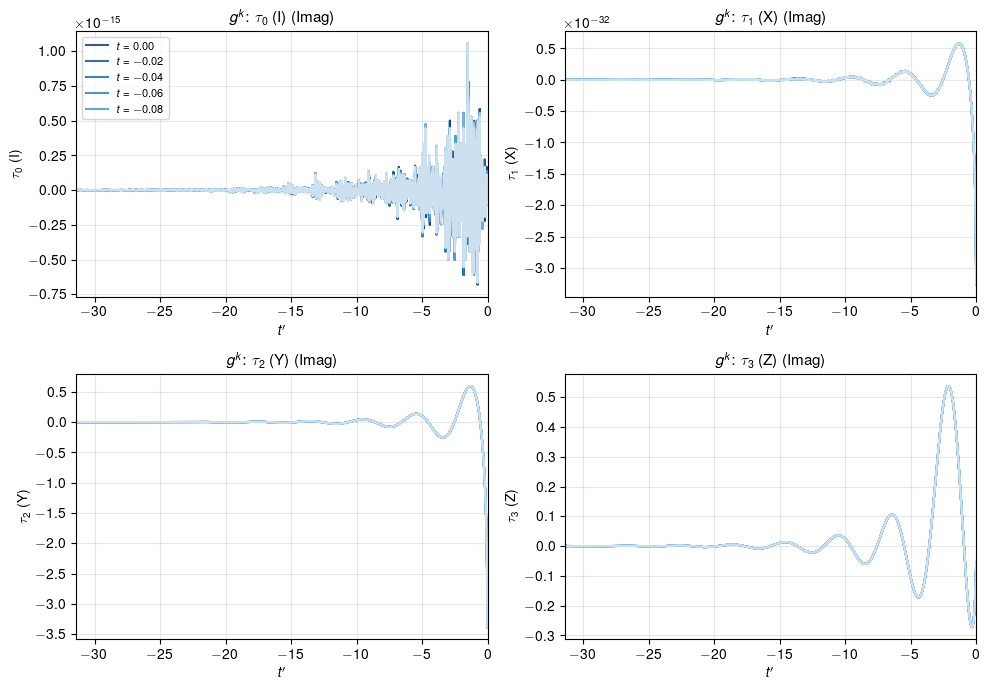


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456), np.float64(1.5485711133152456)]
  gr max diff: 1.55e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231), np.float64(5.062938120445231)]
  gk max diff: 5.06e+00 (in row 2 from last)

  Passed (threshold 1e-08): False


In [8]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

# 2. Gap and Current Analysis


Input Parameters (timestamp=1781598564, job_index=0):
  num_timesteps: 500
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: 1781556773
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  field_type: None
  field_params: None
  track_every_n: None
  save_full_state: True
  save_filename: /cluster/work/demler/project_active/fmarijanovic/savefiles/psBQP-keldysh/simulation_results/1781598564/results/sr_0



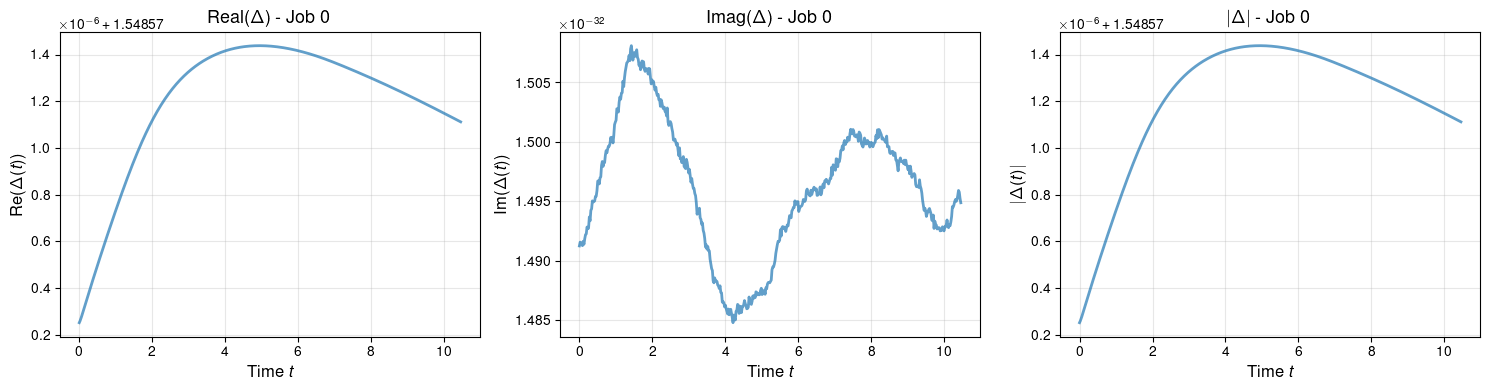

In [9]:
# Plot gap evolution for this job
da.plot_gap(check_timestamp, check_job_index, save_plot=False)


Input Parameters (timestamp=1781598564, job_index=0):
  num_timesteps: 500
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: 1781556773
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  field_type: None
  field_params: None
  track_every_n: None
  save_full_state: True
  save_filename: /cluster/work/demler/project_active/fmarijanovic/savefiles/psBQP-keldysh/simulation_results/1781598564/results/sr_0



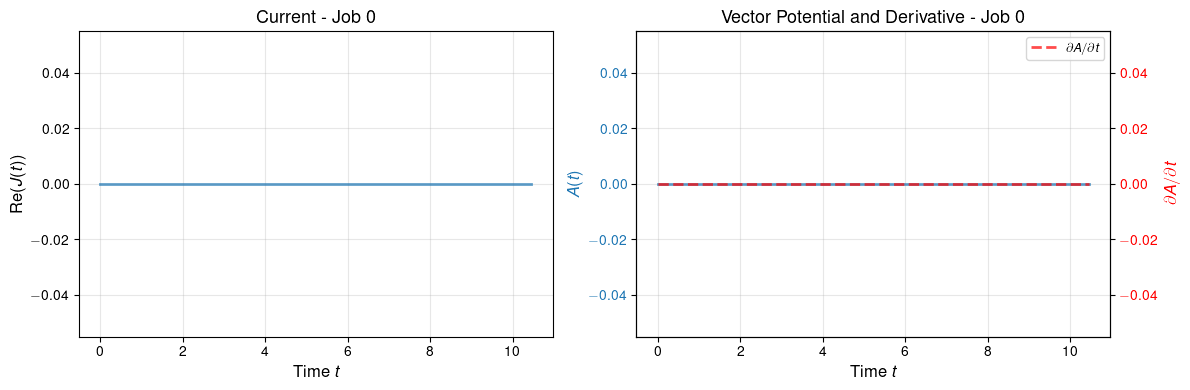

In [10]:
# Plot current evolution for this job
da.plot_current(check_timestamp, check_job_index, save_plot=False)


# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [11]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1780988799']  # Add more timestamps as needed: ['ts1', 'ts2', ...]

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1780988799']
Averaging last 100 timesteps


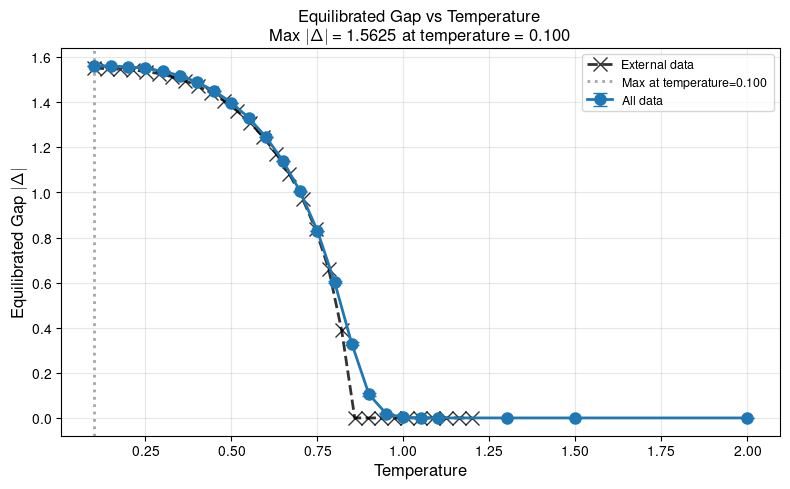


Gap Sweep Results:
  Parameter values: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.3  1.5  2.  ]
  Gap means: [ 1.56254486e+00+1.32947211e-32j  1.56063213e+00+9.66192254e-33j
  1.55701538e+00+8.40404488e-33j  1.55002774e+00+1.00773938e-32j
  1.53770507e+00+1.25092661e-32j  1.51812789e+00+8.05432888e-33j
  1.48952571e+00+7.85354248e-33j  1.45017784e+00+7.12082787e-33j
  1.39822599e+00+1.05407088e-32j  1.33142374e+00+1.24848011e-32j
  1.24677747e+00+8.64277586e-33j  1.13997247e+00+7.27405585e-33j
  1.00440746e+00+8.93663118e-33j  8.29827303e-01+9.26507152e-33j
  6.03046256e-01+5.94724515e-33j  3.29531833e-01+3.21994823e-33j
  1.04655705e-01+1.33718333e-33j  1.88594971e-02+3.06250009e-34j
  2.39810830e-03+7.26749808e-35j  2.48982523e-04+1.29787891e-35j
  2.23523981e-05+4.24543960e-36j  1.02610616e-07+3.43352906e-37j
  2.13467407e-08-1.01007452e-38j -1.82781036e-09+3.98887029e-39j]
  Gap errors: [3.13636115e-07 4.84731106e-0

In [12]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps, 
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True,
    x_external = eq_T, y_external = eq_gap_mag_T
)


print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

In [13]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1780988780']  # Add more timestamps as needed: ['ts1', 'ts2', ...]

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'vector_potential'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: vector_potential
Timestamps to analyze: ['1780988780']
Averaging last 100 timesteps


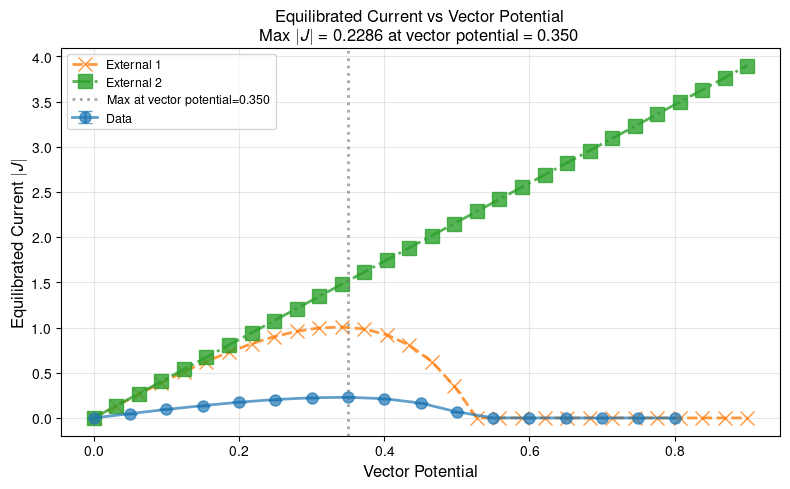

In [14]:
# Plot equilibrated current vs parameter

current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,eq_A], y_external = [eq_current_A, eq_A * np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.5)]
)
#* added 1/2 factor for comparison since original current heory was wrong so to rescale. -- fixed in new version 

#print(np.pi * 1.51812789 * np.tanh(1.51812789/2 / 0.3)/2)
#print(np.max(eq_current_A))

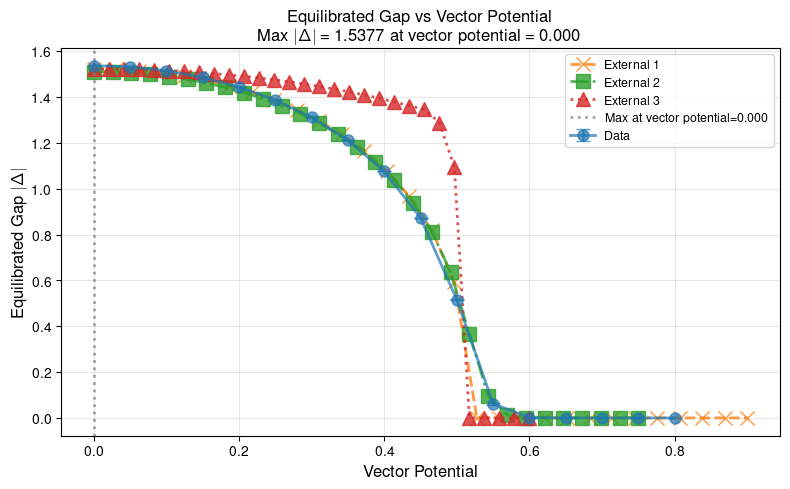

In [15]:
x_jon = [0.        , 0.02586207 ,0.05172414 ,0.07758621 ,0.10344828, 0.12931034,
 0.15517241, 0.18103448, 0.20689655, 0.23275862, 0.25862069, 0.28448276,
 0.31034483, 0.3362069 , 0.36206897, 0.38793103, 0.4137931,  0.43965517,
 0.46551724, 0.49137931, 0.51724138, 0.54310345, 0.56896552, 0.59482759,
 0.62068966, 0.64655172, 0.67241379, 0.69827586, 0.72413793, 0.75]
y_jon = [1.51163408e+00, 1.51027885e+00, 1.50620005e+00, 1.49935768e+00,
 1.48968270e+00, 1.47707321e+00, 1.46138854e+00, 1.44244072e+00,
 1.41998222e+00, 1.39368837e+00, 1.36313217e+00, 1.32774717e+00,
 1.28677174e+00, 1.23916228e+00, 1.18345224e+00, 1.11750939e+00,
 1.03808374e+00, 9.39867391e-01, 8.13187470e-01, 6.36954560e-01,
 3.67131713e-01, 9.64004201e-02, 1.35302658e-02, 1.55015802e-03,
 1.64641301e-04, 1.68474568e-05, 1.68997743e-06, 1.67848029e-07,
 1.66168484e-08, 9.13836357e-09]

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, x_external = [eq_A,x_jon,eq_A_trash], y_external = [eq_gap_mag_A,y_jon,eq_gap_mag_A_trash]
)




## Quasi-particle evolution dynamics 

In [16]:
qp_timestamp = '1781535122' 
qp_job_index = 0    

In [17]:
da.plot_energy_time_representation(
    timestamp=qp_timestamp,  # Your timestamp
    job_index=qp_job_index,    # Your job index
    green_function_type='f',
    pauli_components=(0, 3),  # tau_0 and tau_3
    plot_every= 1,             # Plot every 5th time slice
    save_plot=True
)


FileNotFoundError: Kwargs file not found for timestamp 1781535122